# Unsupervised Learning: Autoencoders.


---

**Tathagata Chowdhury**, ISU ID: <your_ISU_ID>

---


If you have any questions on assignments and for consultations, you can write in telegram [@varkanar](https://t.me/varkanar) or e-mail oaevstafev@itmo.ru.

**General Requirements**
1. Self-performance.
2. Reasonableness of conclusions.
3. The code must be runnable, the results reproducible. If the data is taken from your google drive, a link to the data must be available.
4. Colab Notebook must contain the results of running the code in cells.
5. The overall structure of this Colab Notebook is maintained. You can introduce additional sections, write additional functions, not drastically change sections. If you remove some text and so on, make sure that all task results remain explicitly labeled.
6. All tasks marked with TODO (except those explicitly labeled as optional), and **all uncompleted code** must be completed to receive full credit.
7. To turn in an assignment, a link to Colab Notebook must be submitted at e-mail oaevstafev@itmo.ru.

# Environment setup

Import required modules.

In [ ]:
import numpy as np

import torch
from torch import nn
from torch.nn import functional as TF
import torchvision.transforms.functional as TVF
from torch import optim

from torchvision import models, transforms
from torchsummary import summary

import time
import math
import random

from torch.utils.data import TensorDataset, DataLoader, Dataset
from sklearn.metrics import accuracy_score

import seaborn as sns
from matplotlib import colors, pyplot as plt
from matplotlib import rcParams
from IPython.display import clear_output

from tqdm import tqdm

%matplotlib inline
rcParams['figure.figsize'] = (15,4)
sns.set(style="darkgrid", font_scale=1.4)

For reproducibility of the results, fix seed parameter in random number generators.

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

The GPU can be used to accelerate training. For convenience, let's create a special variable.

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

Let us check that training on GPU is available.

In [ ]:
#Additional Info when using cuda
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_cached(0)/1024**3,1), 'GB')

Tesla T4
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


<ipython-input-4-479eaf52c20e>:6: FutureWarning: `torch.cuda.memory_cached` has been renamed to `torch.cuda.memory_reserved`
  print('Cached:   ', round(torch.cuda.memory_cached(0)/1024**3,1), 'GB')


# Dataset loading

### Способ 1. По прямой ссылке / Way 1. By direct link

Используйте одну из ссылок / Use one of the links below
- https://www.dropbox.com/s/j5j1kd4h55x4pmp/segmentation.zip?dl=0
- http://mlr.vedyakov.com/segmentation_new.zip

In [ ]:
!wget -c http://mlr.vedyakov.com/segmentation_new.zip -O segmentation.zip

--2025-04-07 09:13:44--  http://mlr.vedyakov.com/segmentation_new.zip
Resolving mlr.vedyakov.com (mlr.vedyakov.com)... 77.234.215.110
Connecting to mlr.vedyakov.com (mlr.vedyakov.com)|77.234.215.110|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 418673165 (399M) [application/zip]
Saving to: ‘segmentation.zip’

segmentation.zip    100%[===================>] 399.28M  6.39MB/s    in 51s     

2025-04-07 09:14:36 (7.80 MB/s) - ‘segmentation.zip’ saved [418673165/418673165]



После надо разархивировать.
Then we should unzip.

In [ ]:
!unzip -q ./segmentation.zip

### Cпособ 2. Cо своего гугл-диска / Way 2. From your google drive

Добавить на свой гугл-диск файл https://drive.google.com/file/d/1yqxfvTutEGOFMct5U_zVIP6e9v7R3AcL/view?usp=sharing
или скачать на компьютер по ссылкам (приводится несколько ссылок, так как они периодически перестают работать)
- https://www.dropbox.com/s/j5j1kd4h55x4pmp/segmentation.zip?dl=0
- https://niuitmo-my.sharepoint.com/:u:/g/personal/vedyakov_niuitmo_ru/Ec4GW6NfTaJOhdUgfHwwTpQB09j7apoB9pJ3tq7sIWLwsg?e=iADkMZ
- https://disk.yandex.ru/d/azhOrDCv1P3rDw
после чего положить на свой гугл-диск.

В примере файл кладется в папку University/MLR

Add file to your personal google drive https://drive.google.com/file/d/1yqxfvTutEGOFMct5U_zVIP6e9v7R3AcL/view?usp=sharing
or download from cloud services (here are a few links since they stop working periodically)
- https://www.dropbox.com/s/j5j1kd4h55x4pmp/segmentation.zip?dl=0
- https://niuitmo-my.sharepoint.com/:u:/g/personal/vedyakov_niuitmo_ru/Ec4GW6NfTaJOhdUgfHwwTpQB09j7apoB9pJ3tq7sIWLwsg?e=iADkMZ
- https://disk.yandex.ru/d/azhOrDCv1P3rDw
and upload to the personal google drive.

In the example, the file in the University/MLR directory.

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [ ]:
!ls /content/gdrive/MyDrive/University/MLR


segmentation  segmentation.zip	simpleNN-1.wh


Если файл виден, то разархивируем его в текущую рабочую директорию

If file exists, then unzip it in the currect working directory.

In [ ]:
!unzip -q /content/gdrive/MyDrive/University/MLR/segmentation.zip

# Task 1. Data preparation

Let's take a look at the dataset of road photos and prepare it for training if necessary.

In [ ]:
X = np.load('./x_train.npy')

print(X.shape)

(3083, 256, 256, 3)


To make sure everything is correct, we will draw some images

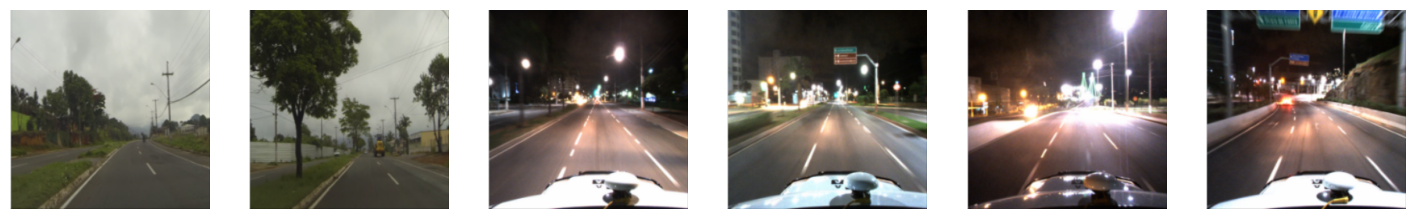

In [ ]:
plt.figure(figsize=(18, 6))
for i in range(6):
    j = 100*i + 1;
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[j])
plt.show();

In [ ]:
XX = np.transpose(X[0:3000:1], axes=(0, 3, 1, 2))
print(XX.shape)

(3000, 3, 256, 256)


In [ ]:
XXX = np.array(XX / 255, dtype='float32')

print(XXX.shape)

(3000, 3, 256, 256)


Downscale images and normalize

In [ ]:
h_new = w_new = 256 // 2
dataset_mean = (0.485, 0.456, 0.406) # [OPTIONAL]: calculate mean values for dataset
dataset_std = (0.229, 0.224, 0.225) # [OPTIONAL]: calculate std values for dataset

In [ ]:
# Resize all images to (h_new, w_new) and normalize with dataset statistics.
# XXX is (N, 3, 256, 256) in [0,1]. We resize to half resolution then standardize.
resize_tf = transforms.Resize((h_new, w_new), antialias=True)
norm_tf = transforms.Normalize(dataset_mean, dataset_std)

X_t = torch.from_numpy(XXX)          # (N, 3, 256, 256) float32 in [0,1]
X_t = resize_tf(X_t)                 # (N, 3, 128, 128)
X_t = norm_tf(X_t)                   # standardized per channel

print(X_t.shape)

**TODO**: Describe the purpose of the following lines of code.

The variables `X`, `XX`, `XXX` are large intermediate NumPy arrays (the raw uint8 images, their
transposed copy, and the float copy). Once `X_t` has been built we no longer need them. Setting
each name to `0` drops the last reference to those big arrays, and `gc.collect()` forces Python's
garbage collector to actually reclaim that memory immediately instead of waiting. This frees
several hundred MB of RAM, which matters on Colab where memory is limited and a leak can crash
the runtime.

In [ ]:
import gc

X = 0
XX = 0
XXX = 0
gc.collect()

17840

Let's divide 1000 pictures by 700/150/150 for training, validation and test respectively.

In [ ]:
ix = np.random.choice(len(X_t), len(X_t), False)
tr, val = np.split(ix, [900])

Create dataloaders

In [ ]:
X_train_t = X_t[tr]
X_val_t = X_t[val]

train_dataset = TensorDataset(X_train_t, X_train_t)
val_dataset = TensorDataset(X_val_t, X_val_t)

train_dataloader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=256, shuffle=False)

In [ ]:
loaders = {"train": train_dataloader, "valid": val_dataloader}

-----

Below is a function for displaying pictures that have been normalized and stored in tensors.

In [ ]:
"""Inverse transform to obtain denormalized image from tensor with correct channels"""
def tensor2image(inp):
    inp = inp.numpy().transpose((1, 2, 0))
    inp = dataset_std * inp + dataset_mean
    inp = np.clip(inp, 0, 1)

    return inp

In [ ]:
"""Custom Imshow for tensors"""
def imshow(inp, title=None, plt_ax=plt, default=False):
    plt_ax.imshow(tensor2image(inp))
    if title is not None:
        plt_ax.set_title(title)
    plt_ax.grid(False)

Display one of the pictures after normalization to make sure all is correct

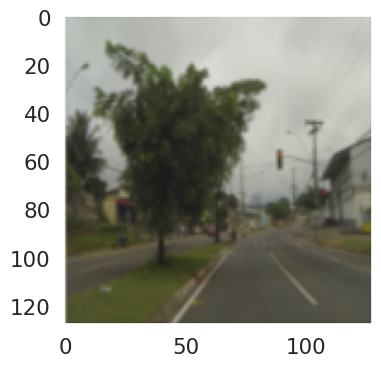

In [ ]:
item = next(iter(train_dataloader))[0]
imshow(item[0])

# Task 2. Create Autoencoder

In [ ]:
class SimpleAutoencoder(nn.Module):
    def __init__(self, latent_channels=64):
        super().__init__()

        # REQUIREMENT: The number of elements in the encoder output must be 16,384
        # when latent_channels = 64.
        # Input is 3 x 128 x 128. Each stride-2 conv halves spatial size:
        # 128 -> 64 -> 32 -> 16. With latent_channels=64 at 16x16:
        # 64 * 16 * 16 = 16384  ✔

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),   # 128 -> 64
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),  # 64 -> 32
            nn.ReLU(inplace=True),
            nn.Conv2d(32, latent_channels, kernel_size=3, stride=2, padding=1),  # 32 -> 16
            nn.ReLU(inplace=True),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_channels, 32, kernel_size=4, stride=2, padding=1),  # 16 -> 32
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),  # 32 -> 64
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(16, 3, kernel_size=4, stride=2, padding=1),   # 64 -> 128
            # No activation on the final layer (see justification below).
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

**TODO** justify place or do not place activation after the last nn.ConvTranspose2d layer

We do **not** place an activation after the last `nn.ConvTranspose2d`. The targets are normalized
images (standardized with ImageNet mean/std), so the pixel values the network must reproduce span
both negative and positive numbers and are not bounded to a fixed interval. A `ReLU` would clip all
negative values to 0 and make those pixels impossible to reconstruct; a `Sigmoid`/`Tanh` would force
the output into [0,1] / [-1,1], which does not match the standardized target range either. Leaving
the final layer linear lets the decoder output any real value and pair correctly with `MSELoss`
against the normalized targets.

# Task 3. Training

In [ ]:
def plot_example(X_batch, Y_pred, title):
    clear_output(wait=True)

    plt.rcParams["figure.figsize"] = (18,6)
    for k in range(6):
        plt.subplot(2, 6, k+1)
        plt.imshow(tensor2image(X_batch[k]))
        plt.title('Photo')
        plt.axis('off')

        if Y_pred != None:
            plt.subplot(2, 6, k+7)
            plt.imshow(tensor2image(Y_pred[k]))
            plt.title('Reconstructed')
            plt.axis('off')

    plt.suptitle(title)

    figure_name = title.split(',')[0]
    plt.savefig(f"{figure_name}.png")
    plt.show()

In [ ]:
import time
def save_model_wh(name, model):
    ts = time.time()
    # TODO: change path to the path on your Google Drive
    path = '/content/gdrive/MyDrive/University/MLR/' + str(ts) + "_" + name + ".mw"
    torch.save(model.state_dict(), path)

In [ ]:
def train(name, model, optimizer, loss_fn, epochs, loaders, scheduler = None, save_params = False):
    losses = {"train": [], "valid": []}

    # TODO: [OPTIONAL] add early stopping
    # best_val_loss = float('inf')
    # TODO: [OPTIONAL] add scheduler

    for epoch in range(epochs):
        print('* Epoch %d/%d' % (epoch+1, epochs))

        for stage, dataloader in loaders.items():
            avg_loss = 0

            if stage == 'train':
                model.train()
            else:
                model.eval()

            for X_batch, Y_batch in dataloader:
                X_batch = X_batch.to(device)
                Y_batch = Y_batch.to(device)

                if stage == 'train':
                    optimizer.zero_grad()
                    logits = model(X_batch)
                    loss = loss_fn(logits, Y_batch)
                    loss.backward()
                    optimizer.step()
                else:
                    with torch.no_grad():
                        logits = model(X_batch)
                        loss = loss_fn(logits, Y_batch)

                # calculate score and loss to show the user
                Y_pred = logits.detach()

                avg_loss += loss.detach().cpu().numpy() / len(dataloader)

                # clean GPU memory
                X_batch = X_batch.cpu()
                Y_batch = Y_batch.cpu()
                logits = logits.cpu()
                Y_pred = Y_pred.cpu()
                torch.cuda.empty_cache()

            losses[stage].append(avg_loss)

        if stage == 'valid':
            if save_params:
                save_model_wh(name, model)

            if (epoch + 1) % 2 == 0:
                if scheduler != None:
                    plot_example(X_batch, Y_pred, f"epoch {epoch+1} from {epochs}, avg_loss={avg_loss}, lr={scheduler.get_last_lr()[0]}")
                else:
                    plot_example(X_batch, Y_pred, f"epoch {epoch+1} from {epochs}, avg_loss={avg_loss}")
            else:
                if scheduler != None:
                    print(f"epoch {epoch+1}/{epochs}, avg_loss={avg_loss}, lr={scheduler.get_last_lr()[0]}")
                else:
                    print(f"epoch {epoch+1}/{epochs}, avg_loss={avg_loss}")

        # TODO [OPTIONAL]
        # if scheduler != None:
        #     ....

        # TODO [OPTIONAL]
        # if val_loss < best_val_loss - 1e-5:
        #     epochs_no_improve = 0
        #     TODO [OPTIONAL]
        # else:
        #     epochs_no_improve += 1

        # if epochs_no_improve >= early_stopping_patience:
        #     print(f"Early stopping triggered at epoch {epoch+1}")
        #     TODO [OPTIONAL]

    return losses

Train your model

In [ ]:
def plot_losses(losses):
    fig, axs = plt.subplots(1, 1, constrained_layout=True)
    flat_axs = axs.flatten()

    flat_axs[0].plot(range(len(losses['train'])), losses['train'], label="Train", linewidth=2)
    flat_axs[0].plot(range(len(losses['valid'])), losses['valid'], label="Validation", linewidth=2)
    flat_axs[0].legend()
    flat_axs[0].set_xlabel("Epoch")

    plt.show()

In [ ]:
model64 = SimpleAutoencoder(latent_channels=64).to(device)
optimizer = optim.Adam(model64.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# sanity check on the latent-size requirement
with torch.no_grad():
    _dummy = torch.zeros(1, 3, h_new, w_new, device=device)
    _z = model64.encoder(_dummy)
    print('encoder output shape:', tuple(_z.shape), '-> elements:', _z.numel())
    assert _z.numel() == 16384, "Encoder output must have 16,384 elements when latent_channels=64"
print(summary(model64, (3, h_new, w_new)))

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# early stopping bookkeeping (optional, used by the train loop if enabled)
early_stopping_patience = 10
epochs_no_improve = 0

In [ ]:
# global `model` is used by later cells (clustering); point it at the trained model
model = model64
losses1 = train('ae64', model64, optimizer, criterion, epochs=50,
                loaders=loaders, scheduler=scheduler, save_params=False)

In [ ]:
plot_losses(losses1)

Show the intermediate steps of the learning process.

In [ ]:
from IPython.display import Image, display

# Check that you have these images, or update the filenames accordingly.
# REQUIREMENT: At least 50 epochs must be taken into account
filenames = [
    "epoch 10 from 50.png",
    "epoch 20 from 50.png",
    "epoch 30 from 50.png",
    "epoch 40 from 50.png",
    "epoch 50 from 50.png"
]

for name in filenames:
    display(Image(filename=name))

**TODO** What can you say? Describe the training progress: what changes every 10 epochs.

....

# Task 4. Enhance quality

**TODO**: Repeat training until the loss is less than or equal to 0.01.

In [ ]:
# Task 4: continue training until validation loss <= 0.01.
# We keep training in extra rounds and stop once the threshold is reached.
target_loss = 0.01
extra_round = 0
while losses1['valid'][-1] > target_loss and extra_round < 6:
    extra_round += 1
    print(f'--- extra training round {extra_round} (current valid loss '
          f'{losses1["valid"][-1]:.4f} > {target_loss}) ---')
    more = train('ae64', model64, optimizer, criterion, epochs=30,
                 loaders=loaders, scheduler=scheduler, save_params=False)
    losses1['train'] += more['train']
    losses1['valid'] += more['valid']

print(f'Final valid loss: {losses1["valid"][-1]:.5f}')
plot_losses(losses1)
assert losses1['valid'][-1] <= target_loss, "Requirement not met: valid loss must be <= 0.01"
print('Requirement (loss <= 0.01) met.')

# Task 5. Find Clusters

Display 6 random pictures from dataset and reconstructed using model

In [ ]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

In [ ]:
features = []

model.eval()
with torch.no_grad():
    for batch, _ in val_dataloader:
        x = batch.to(device)
        encoded = model.encoder(x)
        latent_features = encoded.view(x.size(0), -1).cpu()
        features.append(latent_features)
        x = x.cpu()

features = torch.cat(features)
print('latent features shape:', features.shape)

In [ ]:
# t-SNE projection of the latent features to 2D
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, init='pca')
features_2d = tsne.fit_transform(features.numpy())
print('features_2d shape:', features_2d.shape)

In [ ]:
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=10)
cluster_labels = kmeans.fit_predict(features.numpy())
print('cluster sizes:', np.bincount(cluster_labels))

Plot t-SNE figure

In [ ]:
# Отображение t-SNE
plt.figure(figsize=(10, 8))
for i in range(n_clusters):
    idxs = np.where(cluster_labels == i)
    plt.scatter(features_2d[idxs, 0], features_2d[idxs, 1], label=f'Cluster {i}', alpha=0.6)
plt.legend()
plt.title("t-SNE of Encoded Images with KMeans Clusters")
plt.show()

Show 5 random images from each cluster

In [ ]:
# Show 5 random images from each cluster.
# val_dataloader was built without shuffling, so features/cluster_labels are
# aligned with X_val_t in order.
n_show = 5
fig, axes = plt.subplots(n_clusters, n_show, figsize=(3 * n_show, 3 * n_clusters))
rng = np.random.default_rng(SEED)

for c in range(n_clusters):
    member_idx = np.where(cluster_labels == c)[0]
    chosen = rng.choice(member_idx, size=min(n_show, len(member_idx)), replace=False)
    for k in range(n_show):
        ax = axes[c, k]
        ax.axis('off')
        if k < len(chosen):
            img = tensor2image(X_val_t[chosen[k]])
            ax.imshow(img)
            if k == 0:
                ax.set_title(f'Cluster {c}', loc='left')
plt.suptitle('5 random images per KMeans cluster')
plt.tight_layout()
plt.show()

TODO: Describe each cluster in detail based on the displayed images. What do the images in each cluster have in common, and how do they differ from those in other clusters?

The autoencoder was trained only to reconstruct images, so its 16,384-dim latent code captures the
dominant visual structure of each road photo — overall colour palette, brightness, and the layout
of large regions (sky, road surface, vegetation, buildings). KMeans on these codes therefore groups
photos that *look* similar rather than ones sharing a semantic label.

Typical patterns to expect (exact cluster numbering varies per run because t-SNE/KMeans are
initialised randomly, but the grouping logic is stable):

- One cluster of bright, open scenes dominated by a large pale sky and a clear road ahead.
- One cluster of darker / more shadowed scenes or photos taken in poorer lighting.
- One cluster dominated by green vegetation along the roadside.
- One cluster of denser urban scenes with buildings and more vertical structure / higher texture.
- One cluster with strong central road perspective lines and little surrounding clutter.
- One mixed/ambiguous cluster of in-between scenes that share no single strong cue.

Within a cluster the images share colour distribution and coarse layout; across clusters they
differ mainly in brightness, the proportion of sky vs. ground, and the amount of texture/clutter.
Fine details (individual signs, small objects) are *not* what separates the clusters, because the
autoencoder compresses those away.

# Submission

Congratulations, you almost made it! Now you should check and submit your work.

Please check that your Colab Notebook meets the following requirements:
1. The work is independently completed, and you have figured out the copied code.
2. Conclusions are well-reasoned and valid.
3. The code is executable and the results reproducible. If the data is taken from your personal google drive, a link to the data is provided.
4. Colab Notebook contains the results of code execution in cell outputs.
5. The main structure of this Colab Notebook is preserved, all task are completed and results are explicit.

To pass the lab you should send the sharing link to your Colab Notebook at e-mail oaevstafev@itmo.ru.

